# Régression linéaire univariée 

---
## Imports

In [1]:
# DatFrame & Dataviz
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Import du modèle de regression linéaire
from sklearn.linear_model import LinearRegression

In [2]:
# Chargement du dataset
link = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/weather2019.csv"
# Chargement du dataset dans un DataFrame pandas
df_weather = pd.read_csv(link)
# Filtre des colonnes necessaire à l'exercice
df_weather = df_weather.iloc[:,[0,1,2, -4]]
df_weather['DATE'] = pd.to_datetime(df_weather['DATE'])
# Affichage du DataFrame
df_weather.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR
0,2019-01-01,9,4,5.1
1,2019-01-02,8,5,8.7
2,2019-01-03,6,0,8.7
3,2019-01-04,5,-1,5.1
4,2019-01-05,6,-1,8.7


---
## Explaration Data Analysis

In [3]:
# Affichage des corrélations entre valeurs numériques (sans DATE qui n'est pas une valeur numérique)
df_weather.drop('DATE',axis=1).corr()

,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR
MAX_TEMPERATURE_C,1.000000,0.876892,0.690323
MIN_TEMPERATURE_C,0.876892,1.000000,0.471559
SUNHOUR,0.690323,0.471559,1.000000


<Axes: xlabel='MIN_TEMPERATURE_C', ylabel='MAX_TEMPERATURE_C'>

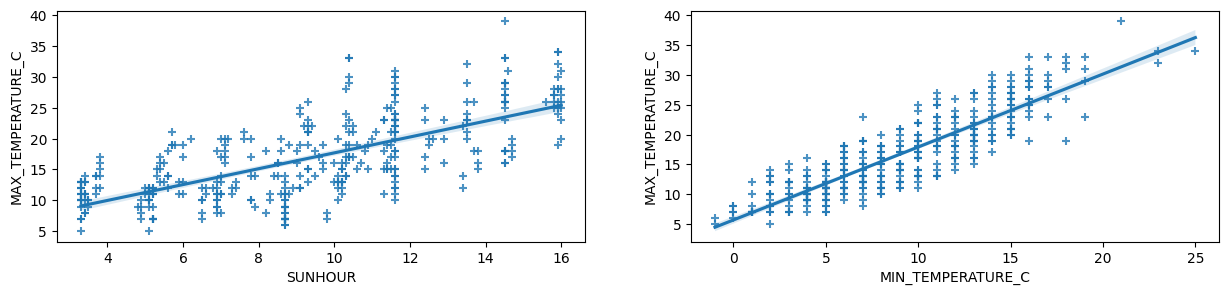

In [4]:
# regplot d'une régression linéaire entre les heures d'ensoleillement (SUNHOUR) et température maximale (MAX_TEMPERATURE_C)
# Comme pour le tableau de corrélation, on voit clairement que la colonne MIN_TEMPERATURE_C à moins de dispersion
fir, axes = plt.subplots(1,2, figsize=(15,3))
sns.regplot(x=df_weather.SUNHOUR,y=df_weather.MAX_TEMPERATURE_C,marker='+', ax=axes[0])
sns.regplot(x=df_weather.MIN_TEMPERATURE_C,y=df_weather.MAX_TEMPERATURE_C,marker='+', ax=axes[1])

---
## Entraînement du modèle

In [5]:
# Définition de la feature (X) et de la target (y)
# X étant une Serie pandas pour une regression linéaire `univarié`
X = df_weather[['SUNHOUR']]
y = df_weather['MAX_TEMPERATURE_C']
# Entrainement du modèle
model = LinearRegression()

### Explorons le modèle

Il s'agit ici d'une Régression Linéaire.  
On veut déterminer une droite avec la formule f(x) = a.X + b  
Pour cela on veut déterminer a et b avec le coefficient et l'interception.  

y = f(x) ... la target à prédire  
.coef_ = a ... le coefficient directeur (la pente)  
X = x ... la feature  
.intercept_ = b ... l'ordonnée à l'origine  

In [6]:
# Entraînement du modèle
model.fit(X, y)
# === REGRESSION LINEAIRE méthode MANUELLE===
# MAX_TEMPERATURE = a * SUNHOUR + b
a = model.coef_      # Coefficient : c'est le "a" dans votre équation "aX + b"
b = model.intercept_ # Intercept : c'est le "b" dans votre équation "aX + b"

# === REGRESSION LINEAIRE méthose PREDICT ===
# La méthode .predict() exécute directement l'équation
y_pred = model.predict(X)

In [7]:
# On stock le résultat de la prédiction (y_pred) dans une nouvelle colonne 'pPREDICTION' du DataFrame.
df_weather['PREDICTION'] = y_pred
df_weather.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR,PREDICTION
0,2019-01-01,9,4,5.1,11.396823
1,2019-01-02,8,5,8.7,16.020019
2,2019-01-03,6,0,8.7,16.020019
3,2019-01-04,5,-1,5.1,11.396823
4,2019-01-05,6,-1,8.7,16.020019


### Visualisations
Les prédictions sont en rouge

1er graphique
- Axe X : Heures d'ensoleillement (SUNHOUR)
- Axe Y : Températures maximales (MAX_TEMPERATURE_C) 
2ème graphique
- Axe X : Date (DATE)
- Axe Y : Températures maximales (MAX_TEMPERATURE_C) 

<Axes: xlabel='DATE', ylabel='MAX_TEMPERATURE_C'>

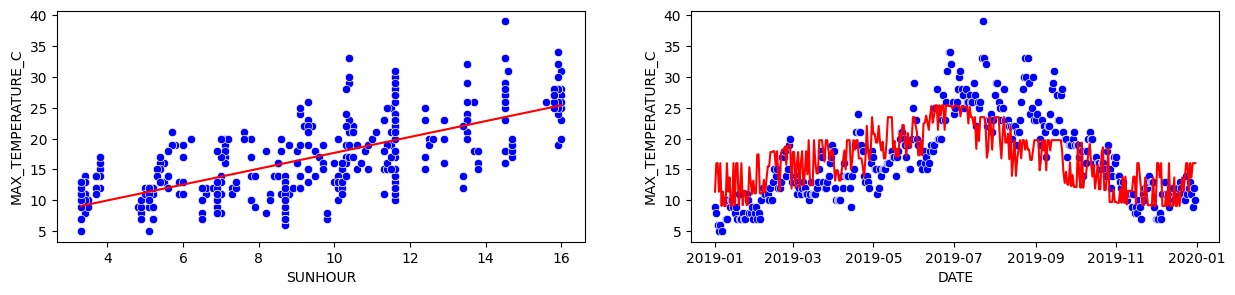

In [8]:
# Axe X : Heures d'ensoleillement (SUNHOUR)
# Axe Y : Températures maximales (MAX_TEMPERATURE_C)
# Axe Y : Prédiction des températures maximales
fig, axes = plt.subplots(1, 2, figsize=(15,3))
sns.scatterplot(data=df_weather, x=df_weather.SUNHOUR, y=df_weather.MAX_TEMPERATURE_C, color='blue', ax=axes[0])
sns.lineplot(data=df_weather, x=df_weather.SUNHOUR, y=df_weather.PREDICTION, color='red', ax=axes[0])
# Axe X : Date
# Axe Y : Températures maximales (MAX_TEMPERATURE_C)
# Axe Y : Prédiction des températures maximales
sns.scatterplot(data=df_weather, x=df_weather.DATE, y=df_weather.MAX_TEMPERATURE_C, ax=axes[1], color='blue')
sns.lineplot(data=df_weather, x=df_weather.DATE, y=df_weather.PREDICTION, ax=axes[1], color='red')

---
## Prédictions sur une colonne plus corrélée
On a observer une corrélation plus forte à partir de la colonne "MIN_TEMPERATURE_C".

In [9]:
# On redéfini la feature qui correspond à la colonne plus corrélé (MIN_TEMPERATURE_C)
X = df_weather[['MIN_TEMPERATURE_C']]
y = df_weather.MAX_TEMPERATURE_C

In [10]:
# Entrainement du modèle
model.fit(X,y)
# Prédiction sur la feature pour obtenir la target qui est injecté dans une colonne du DataFrame (PREDICTION2)
df_weather['PREDICTION2'] = model.predict(X)

In [11]:
# Affichage du nouveau DataFrame
df_weather.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR,PREDICTION,PREDICTION2
0,2019-01-01,9,4,5.1,11.396823,10.579999
1,2019-01-02,8,5,8.7,16.020019,11.802741
2,2019-01-03,6,0,8.7,16.020019,5.689031
3,2019-01-04,5,-1,5.1,11.396823,4.466289
4,2019-01-05,6,-1,8.7,16.020019,4.466289


### Visualisation  
Les prédictions sont en rouge  

1er graphique
- Axe X : Température minimale (MIN_TEMPERATURE_C)
- Axe Y : Température maximale (MAX_TEMPERATURE_C)
2ème graphique
- Axe X : Date (DATE)
- Axe Y : Températures maximales (MAX_TEMPERATURE_C) 

<Axes: xlabel='DATE', ylabel='MAX_TEMPERATURE_C'>

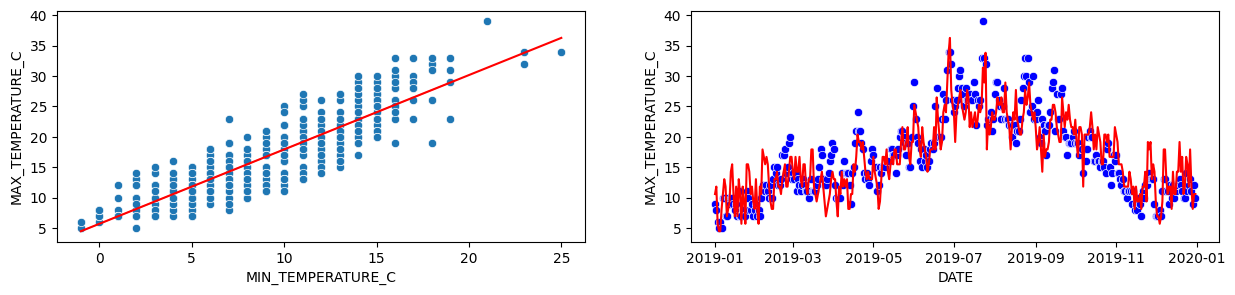

In [12]:
fig, axes = plt.subplots(1,2, figsize=(15,3))
# Axe X : Température minimales (MIN_TEMPERATURE_C)
# Axe Y : Températures maximales (MAX_TEMPERATURE_C)
# Axe Y : Prédiction des températures maximales
sns.scatterplot(data=df_weather, x= df_weather.MIN_TEMPERATURE_C, y=df_weather.MAX_TEMPERATURE_C, ax=axes[0])
sns.lineplot(data=df_weather, x= df_weather.MIN_TEMPERATURE_C, y=df_weather.PREDICTION2, color ='red', ax=axes[0])
# Axe X : Date
# Axe Y : Températures maximales (MAX_TEMPERATURE_C)
# Axe Y : Prédiction des températures maximales
sns.scatterplot(x=df_weather.DATE, y=df_weather.MAX_TEMPERATURE_C, color= 'blue', ax=axes[1])
sns.lineplot(x=df_weather.DATE, y=df_weather.PREDICTION2, color ='red', ax=axes[1])